# 02 — Cleaning & EDA

Two jobs in this notebook: build the multi-select parser that 75 of our columns need, and get a first visual read on the data that will guide which facts are worth generating in Notebook 3.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = "data"
df = pd.read_csv(f"{DATA_DIR}/results.txt", low_memory=False)
print("Loaded:", df.shape)

Loaded: (49191, 172)


## The multi-select parser

Every "have worked with / want to work with / admired" column is a semicolon-joined string, e.g. `"Python;JavaScript;Rust"`. One function handles all 75 of them — split, strip whitespace, drop empties.

In [6]:
def parse_multiselect(series):
    """Turn a semicolon-delimited string column into a Series of lists."""
    return series.dropna().astype(str).apply(lambda x: [v.strip() for v in x.split(";") if v.strip()])


def value_counts_multiselect(series):
    """Frequency count across a multi-select column, plus the number of respondents who answered."""
    parsed = parse_multiselect(series)
    counts = Counter()
    for row in parsed:
        counts.update(row)
    return counts, len(parsed)


# quick check
sample = df["LanguageHaveWorkedWith"].dropna().iloc[0]
print("Raw value: ", sample)
print("Parsed:    ", parse_multiselect(df["LanguageHaveWorkedWith"]).iloc[0])

Raw value:  Bash/Shell (all shells);Dart;SQL
Parsed:     ['Bash/Shell (all shells)', 'Dart', 'SQL']


In [7]:
lang_counts, lang_n = value_counts_multiselect(df["LanguageHaveWorkedWith"])
print(f"Respondents answering: {lang_n}")
for lang, c in lang_counts.most_common(10):
    print(f"  {lang}: {c} ({c/lang_n*100:.1f}%)")

Respondents answering: 31671
  JavaScript: 21005 (66.3%)
  HTML/CSS: 19698 (62.2%)
  SQL: 18633 (58.8%)
  Python: 18410 (58.1%)
  Bash/Shell (all shells): 15503 (49.0%)
  TypeScript: 13859 (43.8%)
  Java: 9358 (29.5%)
  C#: 8852 (27.9%)
  C++: 7485 (23.6%)
  PowerShell: 7371 (23.3%)


## Missing-data policy

We're not training a row-level model, we're computing aggregate statistics — so there's no need to drop incomplete rows globally. The rule instead: **every stat gets computed on whichever respondents actually answered that specific question, and we carry the sample size (N) alongside every number.** A fact built on N=23,000 and a fact built on N=200 are not equally trustworthy, even if the headline number looks the same.

One exception that does need real cleaning: salary. Self-reported compensation has obvious junk in it (people entering `$1` or `$50,000,000`), and averages are sensitive to that in a way medians mostly aren't — but even the median shifts a bit once the extreme values are gone. We'll filter to a sane range rather than trust it blindly.

In [8]:
comp_raw = df["ConvertedCompYearly"].dropna()
comp_clean = comp_raw[(comp_raw >= 1000) & (comp_raw <= 2_000_000)]

print(f"Responses with salary: {len(comp_raw)}")
print(f"After removing values outside $1,000-$2,000,000: {len(comp_clean)} ({len(comp_clean)/len(comp_raw)*100:.1f}% kept)")
print()
print("Before:", comp_raw.describe()[["mean","50%","max"]].to_dict())
print("After: ", comp_clean.describe()[["mean","50%","max"]].to_dict())

Responses with salary: 23947
After removing values outside $1,000-$2,000,000: 23204 (96.9% kept)

Before: {'mean': 101761.53990061386, '50%': 75320.0, 'max': 50000000.0}
After:  {'mean': 95915.3838993277, '50%': 77277.5, 'max': 2000000.0}


## Exploratory charts

Four quick looks — enough to sanity-check the data and spot which slices are worth turning into retrievable facts next.

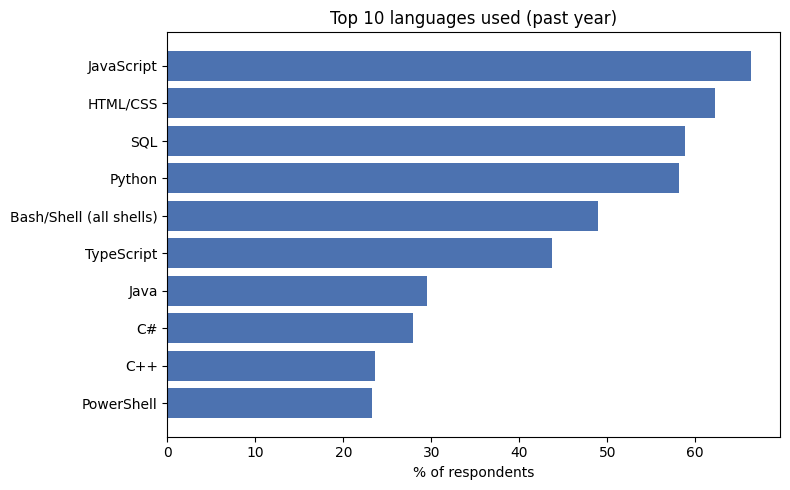

In [9]:
top10 = lang_counts.most_common(10)
names = [x[0] for x in reversed(top10)]
vals = [x[1] / lang_n * 100 for x in reversed(top10)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names, vals, color="#4C72B0")
ax.set_xlabel("% of respondents")
ax.set_title("Top 10 languages used (past year)")
plt.tight_layout()
plt.show()

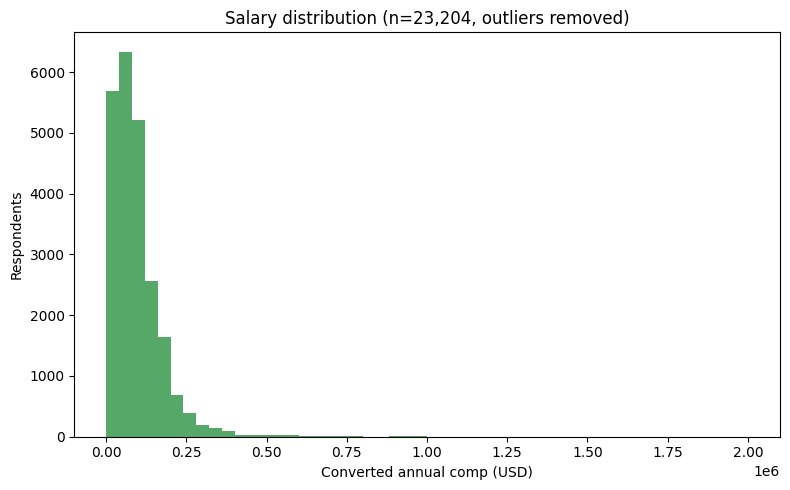

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comp_clean, bins=50, color="#55A868")
ax.set_xlabel("Converted annual comp (USD)")
ax.set_ylabel("Respondents")
ax.set_title(f"Salary distribution (n={len(comp_clean):,}, outliers removed)")
plt.tight_layout()
plt.show()

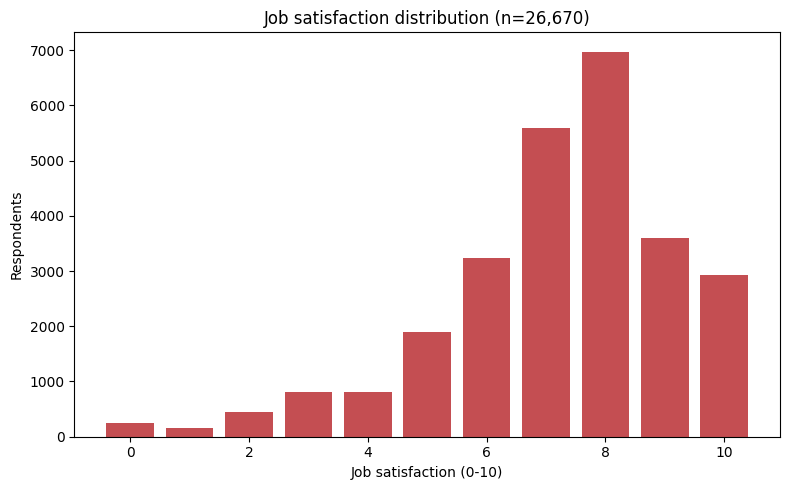

In [11]:
jobsat = df["JobSat"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(jobsat, bins=11, range=(-0.5, 10.5), color="#C44E52", rwidth=0.8)
ax.set_xlabel("Job satisfaction (0-10)")
ax.set_ylabel("Respondents")
ax.set_title(f"Job satisfaction distribution (n={len(jobsat):,})")
plt.tight_layout()
plt.show()

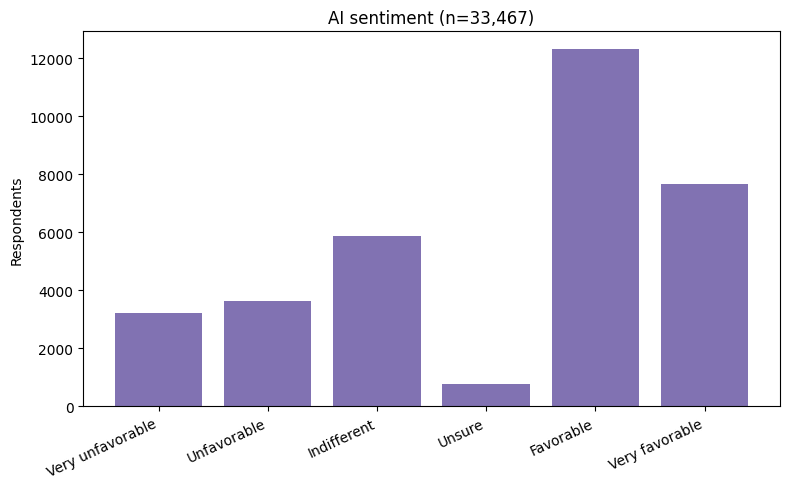

In [12]:
aisent_order = ["Very unfavorable", "Unfavorable", "Indifferent", "Unsure", "Favorable", "Very favorable"]
aisent = df["AISent"].value_counts().reindex(aisent_order).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(aisent_order, aisent.values, color="#8172B2")
ax.set_ylabel("Respondents")
ax.set_title(f"AI sentiment (n={int(aisent.sum()):,})")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## What we learned

- The parser works cleanly across every multi-select column — same function handles languages, databases, platforms, everything
- Salary needs the $1,000–$2,000,000 filter before it's trustworthy; ~97% of responses survive it
- JobSat and AISent are both clean, low-missingness columns once you scope to respondents who answered
- The language, salary, satisfaction, and AI-sentiment breakdowns above are exactly the shape of fact we'll generate systematically in Notebook 3 — same idea, just extended across role, country, and experience cuts instead of one chart each

**Next:** Notebook 3 — deciding the full list of aggregation slices and turning each into a natural-language fact sentence.